<a href="https://colab.research.google.com/github/UghurKhalilov/megaline-surf-vs-ultimate/blob/main/Megaline_Telecom_Revenue_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

## Initialization

In this project, I will analyze the behavior and revenue of 500 Megaline
customers using two prepaid plans: Surf and Ultimate. The goal is to
determine which plan brings in more revenue for the company.

The analysis will include the following steps:
- Data preparation: cleaning, type conversion, and calculating monthly
usage metrics for each user
- Data analysis: studying user behavior (calls, messages, data usage)
per plan using descriptive statistics and visualizations
- Hypothesis testing: statistically testing whether revenue differs
between plans and regions

In [154]:
# Loading all the library
import pandas as pd
import matplotlib.pyplot as plt
import google.colab
import numpy as np

## Load data

In this section, the necessary libraries are imported and all five
datasets are loaded into separate DataFrames for further analysis:
users, calls, messages, internet, and plans.



In [156]:
# Load the data files into different DataFrames
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [157]:
users=pd.read_csv('/content/drive/MyDrive/megaline_dataset/megaline_users.csv')
messages=pd.read_csv('/content/drive/MyDrive/megaline_dataset/megaline_messages.csv')
internet=pd.read_csv('/content/drive/MyDrive/megaline_dataset/megaline_internet.csv')
calls=pd.read_csv('/content/drive/MyDrive/megaline_dataset/megaline_calls.csv')
plans=pd.read_csv('/content/drive/MyDrive/megaline_dataset/megaline_plans.csv')

## Prepare the data

In this section, each dataset is explored and cleaned individually.
Date columns are converted to datetime format, call durations are
rounded up to the nearest minute as per the business rule, and a
month column is extracted from date columns for further monthly
aggregation. Missing values and duplicates are also checked for
each table.

In [158]:
internet.info()
internet.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


## Plans

In [159]:
plans.info()
plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


The plans table has 2 rows (for the Surf and Ultimate plans) and 8
columns: plan_name, usd_monthly_fee, minutes_included, messages_included,
mb_per_month_included, usd_per_minute, usd_per_message, usd_per_gb. All
columns have correct data types, no missing values, no duplicates, and no
unusual or illogical values were observed. This table was manually
created based on the plan details given in the project description.

## Fix data

In [160]:
# No issues requiring correction were found in the plans table

## Enrich data

In [161]:
# No additional enrichment is needed for the plans table, all necessary columns are already present

## Users

In [162]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [163]:
users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
103,1103,Moises,Weeks,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-07-01,surf,NaN
327,1327,Natosha,Peck,20,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-17,surf,NaN
221,1221,Mckenzie,Wilkinson,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-12-17,surf,NaN
102,1102,Marquitta,Walton,30,"Riverside-San Bernardino-Ontario, CA MSA",2018-02-20,ultimate,NaN
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN


The users table has 500 rows and 8 columns. The reg_date and churn_date columns are of object (text) type and need to be converted to datetime. The churn_date column has a large number of missing values, but this is not an error — a missing value means the user was still active (had not cancelled their plan) when the database was extracted. No other issues were found.

### Fix Data

In [164]:
users['reg_date']=pd.to_datetime(users['reg_date'],format='%Y-%m-%d')
users['churn_date']=pd.to_datetime(users['churn_date'],format='%Y-%m-%d')


### Enrich Data

In [165]:
# No additional enrichment is needed for the users table at this stage;
# derived monthly metrics will be calculated later by merging with the calls, messages, and internet tables

## Calls

In [166]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [167]:
calls.sample(5)


,id,user_id,call_date,duration
136786,1495_238,1495,2018-09-06,4.31
107623,1382_301,1382,2018-11-18,8.07
103142,1365_338,1365,2018-07-16,12.66
39920,1147_732,1147,2018-09-06,2.48
106905,1379_103,1379,2018-12-15,16.90


The calls table has a call_date column of object type, which needs to be
converted to datetime. No missing values or duplicates were found.
According to the business rule, each call must be rounded up to the
nearest whole minute, so the duration column requires a correction.

### Fix data

In [168]:
calls['call_date']=pd.to_datetime(calls['call_date'],format='%Y-%m-%d')

### Enrich data

In [169]:
calls['month']=calls['call_date'].dt.month

A new column, month, was added to the calls table by extracting the month
number from the call_date column. This will be useful later for grouping
the data by user_id and month in order to calculate the total number of
calls and total call duration each user made per month.

## Messages

In [170]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [171]:
messages.sample(10)


,id,user_id,message_date
37836,1250_89,1250,2018-10-05
33996,1214_90,1214,2018-08-28
68234,1440_100,1440,2018-10-17
28745,1174_535,1174,2018-12-29
68677,1444_160,1444,2018-08-22
63170,1401_113,1401,2018-09-16
90,1001_160,1001,2018-10-17
23868,1144_357,1144,2018-12-16
29597,1182_8,1182,2018-09-19
57919,1365_75,1365,2018-10-04


The messages table has a message_date column of object type, which needs
to be converted to datetime. No missing values or duplicates were found,
no other corrections are required.

### Fix data

The message_date column was converted from object type to datetime type,
since dates need to be stored in the correct format for further date-based
calculations. No other issues were found in the messages table.

In [172]:
messages['message_date']=pd.to_datetime(messages['message_date'],format='%Y-%m-%d')

### Enrich data

In [173]:
messages['month']=messages['message_date'].dt.month

A new column, month, was added to the messages table by extracting the
month number from the message_date column. This will be used later to
group the data by user_id and month in order to calculate the total
number of text messages each user sent per month.

## Internet

In [174]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [175]:
internet.sample(10)


,id,user_id,session_date,mb_used
25045,1116_167,1116,2018-08-19,161.38
95240,1444_191,1444,2018-12-05,358.57
62573,1287_78,1287,2018-12-21,64.41
73245,1343_103,1343,2018-10-07,1089.80
194,1001_350,1001,2018-09-11,171.14
48801,1217_141,1217,2018-12-30,726.36
94517,1440_155,1440,2018-11-09,46.08
89786,1414_242,1414,2018-10-13,509.52
14688,1066_586,1066,2018-05-04,437.02
76440,1359_121,1359,2018-12-30,0.00


The internet table has a session_date column of object type, which needs
to be converted to datetime. No missing values or duplicates were found,
no other corrections are required.

### Fix data

The session_date column was converted from object type to datetime type,
since dates need to be stored in the correct format for further date-based
calculations. No other issues were found in the internet table.

In [176]:
internet['session_date']=pd.to_datetime(internet['session_date'],format='%Y-%m-%d')

### Enrich data

In [177]:
internet['month']=internet['session_date'].dt.month

A new column, month, was added to the internet table by extracting the
month number from the session_date column. This will be used later to
group the data by user_id and month in order to calculate the total
amount of data (in MB) each user used per month.

## Study plan conditions

In [178]:
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Aggregate data per user

In this section, the cleaned data is aggregated at the user-month
level. For each user, the total number of calls, minutes used,
messages sent, and data consumed per month is calculated.
The results are then merged into a single dataset for revenue
calculation.

In [179]:
# Grouping calls by user_id and month to calculate the total number
# of calls made by each user per month
calls_per_month=calls.groupby(['user_id','month'])['id'].count()
calls_per_month

user_id  month
1000     12       16
1001     8        27
         9        49
         10       65
         11       64
                  ..
1498     12       39
1499     9        41
         10       53
         11       45
         12       65
Name: id, Length: 2258, dtype: int64

In [180]:
# Grouping calls by user_id and month to calculate the total number
# of minutes spent by each user per month
minutes_per_month=calls.groupby(['user_id','month'])['duration'].sum()
minutes_per_month

user_id  month
1000     12       116.83
1001     8        171.14
         9        297.69
         10       374.11
         11       404.59
                   ...  
1498     12       324.77
1499     9        330.37
         10       363.28
         11       288.56
         12       468.10
Name: duration, Length: 2258, dtype: float64

In [181]:
# Grouping messages by user_id and month to calculate the total number
# of messages sent by each user per month
total_messages=messages.groupby(['user_id', 'month'])['id'].count()
total_messages

user_id  month
1000     12       11
1001     8        30
         9        44
         10       53
         11       36
                  ..
1496     9        21
         10       18
         11       13
         12       11
1497     12       50
Name: id, Length: 1806, dtype: int64

In [182]:
# Grouping internet sessions by user_id and month to calculate the total
# volume of data consumed by each user per month
mb_per_month=internet.groupby(['user_id','month'])['mb_used'].count()
mb_per_month

user_id  month
1000     12        5
1001     8        25
         9        53
         10       56
         11       51
                  ..
1498     12       65
1499     9        45
         10       61
         11       49
         12       65
Name: mb_used, Length: 2277, dtype: int64

In [183]:
# Renaming aggregated series for clarity and merging all monthly usage
# metrics (calls, minutes, messages, and data) into a single DataFrame

calls_count = calls_per_month.rename('calls_count')
minutes_used = minutes_per_month.rename('minutes_used')
messages_count = total_messages.rename('messages_count')

total_data = pd.concat([calls_count, minutes_used, messages_count, mb_per_month], axis=1).fillna(0).reset_index()
total_data

,user_id,month,calls_count,minutes_used,messages_count,mb_used
0,1000,12,16.0,116.83,11.0,5.0
1,1001,8,27.0,171.14,30.0,25.0
2,1001,9,49.0,297.69,44.0,53.0
3,1001,10,65.0,374.11,53.0,56.0
4,1001,11,64.0,404.59,36.0,51.0
...,...,...,...,...,...,...
2288,1349,12,0.0,0.00,61.0,27.0
2289,1361,5,0.0,0.00,2.0,9.0
2290,1482,10,0.0,0.00,2.0,0.0
2291,1108,12,0.0,0.00,0.0,2.0


In [184]:
# Add the plan information
plans = plans.rename(columns={'plan_name': 'plan'})

total_data=total_data.merge(users,how='inner')
total_dataset=total_data.merge(plans,on='plan')
total_dataset

,user_id,month,calls_count,minutes_used,messages_count,mb_used,first_name,last_name,age,city,reg_date,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,12,16.0,116.83,11.0,5.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000,30720,3000,70,7,0.01,0.01
1,1001,8,27.0,171.14,30.0,25.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
2,1001,9,49.0,297.69,44.0,53.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
3,1001,10,65.0,374.11,53.0,56.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
4,1001,11,64.0,404.59,36.0,51.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1349,12,0.0,0.00,61.0,27.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaT,50,15360,500,20,10,0.03,0.03
2289,1361,5,0.0,0.00,2.0,9.0,Jacelyn,Hoffman,45,"Birmingham-Hoover, AL MSA",2018-04-14,surf,NaT,50,15360,500,20,10,0.03,0.03
2290,1482,10,0.0,0.00,2.0,0.0,Armand,Glenn,70,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-01,ultimate,NaT,1000,30720,3000,70,7,0.01,0.01
2291,1108,12,0.0,0.00,0.0,2.0,Porfirio,Kane,45,"Salt Lake City, UT MSA",2018-12-30,ultimate,NaT,1000,30720,3000,70,7,0.01,0.01


The plan information is added to the main dataset by merging with
the users and plans tables. Then, monthly revenue is calculated
for each user by comparing actual usage against plan limits and
applying overage charges, plus the fixed monthly fee.

In [185]:
# A custom function is defined to calculate overage costs for each
# usage type (minutes, messages, data). MB is converted to GB before
# calculating data overage. Final monthly revenue is the sum of all
# overage costs plus the fixed monthly fee.
def calc_extra_costs(row, used_col, included_col, price_col):
    diff = row[used_col] - row[included_col]
    diff = max(0, diff)
    cost = diff * row[price_col]
    return cost

# Convert MB to GB (rounded up) before calculating data cost
total_dataset['gb_used'] = np.ceil(total_dataset['mb_used'] / 1024)
total_dataset['gb_included'] = total_dataset['mb_per_month_included'] / 1024

total_dataset['extra_messages_cost'] = total_dataset.apply(
    calc_extra_costs, axis=1,
    used_col='messages_count', included_col='messages_included', price_col='usd_per_message')

total_dataset['extra_minutes_cost'] = total_dataset.apply(
    calc_extra_costs, axis=1,
    used_col='minutes_used', included_col='minutes_included', price_col='usd_per_minute')

total_dataset['extra_mb_cost'] = total_dataset.apply(
    calc_extra_costs, axis=1,
    used_col='gb_used', included_col='gb_included', price_col='usd_per_gb')

total_dataset['revenue'] = (
    total_dataset['extra_messages_cost'] +
    total_dataset['extra_minutes_cost'] +
    total_dataset['extra_mb_cost'] +
    total_dataset['usd_monthly_pay']
)

total_dataset

,user_id,month,calls_count,minutes_used,messages_count,mb_used,first_name,last_name,age,city,...,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_used,gb_included,extra_messages_cost,extra_minutes_cost,extra_mb_cost,revenue
0,1000,12,16.0,116.83,11.0,5.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",...,70,7,0.01,0.01,1.0,30.0,0.00,0.0,0,70.00
1,1001,8,27.0,171.14,30.0,25.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,20,10,0.03,0.03,1.0,15.0,0.00,0.0,0,20.00
2,1001,9,49.0,297.69,44.0,53.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,20,10,0.03,0.03,1.0,15.0,0.00,0.0,0,20.00
3,1001,10,65.0,374.11,53.0,56.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,20,10,0.03,0.03,1.0,15.0,0.09,0.0,0,20.09
4,1001,11,64.0,404.59,36.0,51.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",...,20,10,0.03,0.03,1.0,15.0,0.00,0.0,0,20.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1349,12,0.0,0.00,61.0,27.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",...,20,10,0.03,0.03,1.0,15.0,0.33,0.0,0,20.33
2289,1361,5,0.0,0.00,2.0,9.0,Jacelyn,Hoffman,45,"Birmingham-Hoover, AL MSA",...,20,10,0.03,0.03,1.0,15.0,0.00,0.0,0,20.00
2290,1482,10,0.0,0.00,2.0,0.0,Armand,Glenn,70,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,70,7,0.01,0.01,0.0,30.0,0.00,0.0,0,70.00
2291,1108,12,0.0,0.00,0.0,2.0,Porfirio,Kane,45,"Salt Lake City, UT MSA",...,70,7,0.01,0.01,1.0,30.0,0.00,0.0,0,70.00


## Study user behaviour

In this section, descriptive statistics and visualizations are used
to analyze user behavior across both plans. Usage patterns for calls,
messages, and internet data are compared between Surf and Ultimate
plan users on a monthly basis.

### Calls

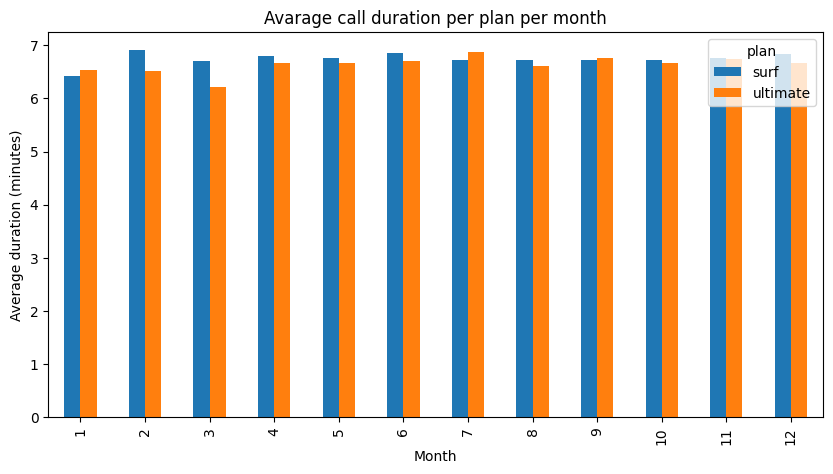

In [186]:
# Merging calls with users to get plan information, then calculating
# the average call duration per plan per month and visualizing it as a bar chart
avarage_minutes=calls.merge(users,on='user_id')
avarage_minutes=avarage_minutes.groupby(['plan','month'])['duration'].mean()

avarage_minutes.unstack(level='plan').plot(kind='bar', figsize=(10,5))
plt.title('Avarage call duration per plan per month')
plt.xlabel('Month')
plt.ylabel('Average duration (minutes)')
plt.show()

The bar chart shows that the average call duration per month is
relatively similar between Surf and Ultimate plan users across all
months, with no significant difference. Both plans show stable
average call durations throughout the year, ranging approximately
between 6 and 7 minutes per call.

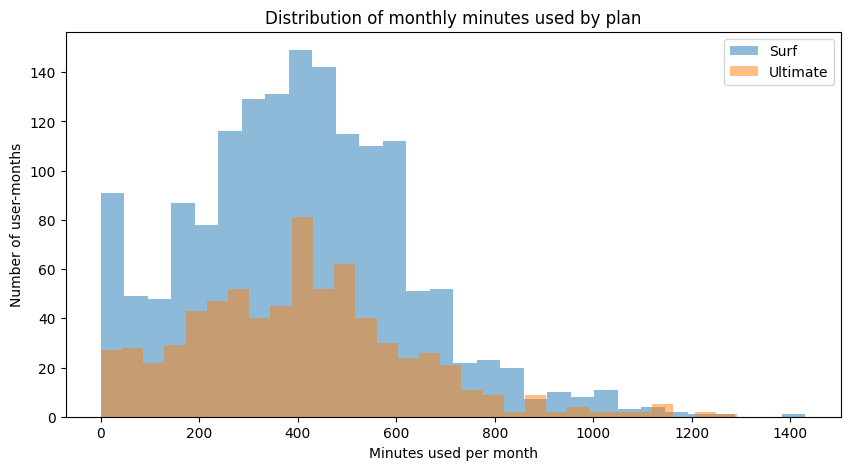

In [187]:
# Comparing the distribution of monthly minutes used by Surf and
# Ultimate plan users using overlapping histograms
surf_minutes = total_dataset[total_dataset['plan'] == 'surf']['minutes_used']
ultimate_minutes = total_dataset[total_dataset['plan'] == 'ultimate']['minutes_used']

plt.figure(figsize=(10,5))
plt.hist(surf_minutes, bins=30, alpha=0.5, label='Surf')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate')
plt.xlabel('Minutes used per month')
plt.ylabel('Number of user-months')
plt.title('Distribution of monthly minutes used by plan')
plt.legend()
plt.show()


The histogram shows that both Surf and Ultimate plan users have a
similar distribution of monthly minutes used, with the majority of
users consuming between 200 and 600 minutes per month. However,
Surf plan users show a longer tail on the right side, meaning some
users significantly exceed the 500-minute limit, resulting in
overage charges. Ultimate plan users are more concentrated in the
lower range, rarely exceeding their generous 3000-minute limit.

In [188]:
# Calculating the mean and variance of monthly minutes used
# for each plan to compare usage patterns statistically
total_dataset.groupby('plan')['minutes_used'].agg(['mean', 'var'])

,mean,var
plan,,
surf,404.762390,49135.104891
ultimate,406.193083,51640.971402


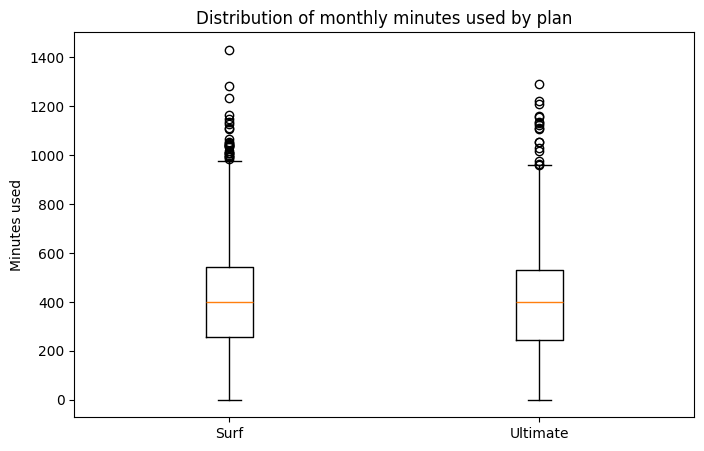

In [195]:
# Box plot to visualize the spread and outliers of monthly
# minutes used for each plan
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([surf_minutes, ultimate_minutes], labels=['Surf', 'Ultimate'])
ax.set_title('Distribution of monthly minutes used by plan')
ax.set_ylabel('Minutes used')
plt.show()


The box plot shows that both plans have a similar median monthly
minutes usage (approximately 400 minutes). Ultimate plan users show
a slightly wider interquartile range (Q1: 246, Q3: 533) with a few
high outliers reaching up to 1292 minutes. Surf plan users show a
comparable distribution. Since most Surf users consume close to or
above their 500-minute limit, they are more likely to incur overage
charges, while Ultimate users rarely approach their 3000-minute limit.

### Messages

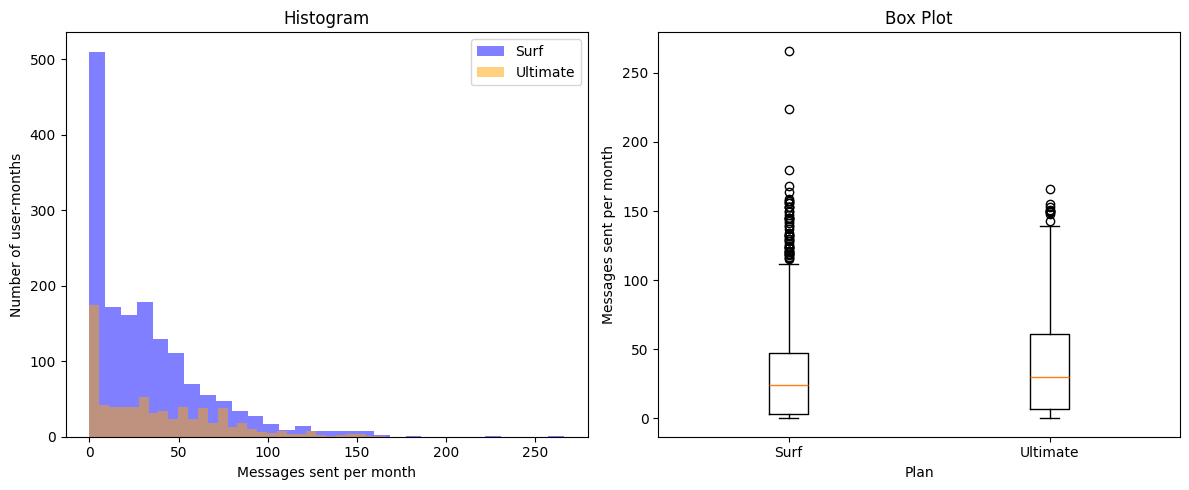

In [197]:
surf_messages = total_dataset[total_dataset['plan'] == 'surf']['messages_count']
ultimate_messages = total_dataset[total_dataset['plan'] == 'ultimate']['messages_count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(surf_messages, bins=30, alpha=0.5, label='Surf', color='blue')
ax1.hist(ultimate_messages, bins=30, alpha=0.5, label='Ultimate', color='orange')
ax1.set_title('Histogram')
ax1.set_xlabel('Messages sent per month')
ax1.set_ylabel('Number of user-months')
ax1.legend()

ax2.boxplot([surf_messages, ultimate_messages], labels=['Surf', 'Ultimate'])
ax2.set_title('Box Plot')
ax2.set_xlabel('Plan')
ax2.set_ylabel('Messages sent per month')
plt.tight_layout()
plt.show()

Both plans show a right-skewed distribution, with the majority of
users sending fewer than 50 messages per month. Surf plan users
have a lower median and a narrower distribution, frequently
exceeding their 50-message limit and incurring overage charges.
Ultimate plan users show a slightly higher median and wider
interquartile range, but rarely exceed their generous 1000-message
limit. The outliers in both groups indicate that some users send
significantly more messages than average.

### Internet

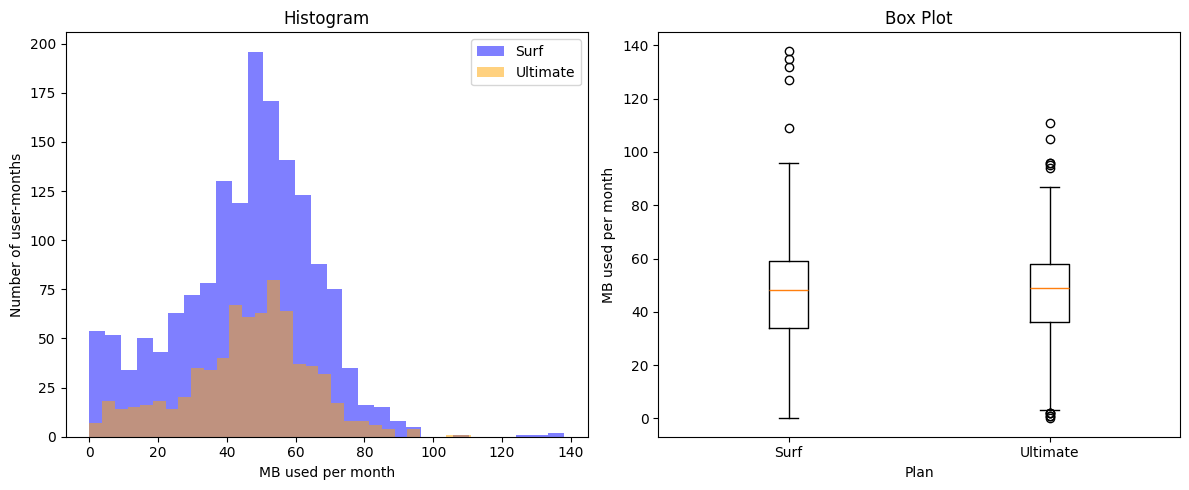

In [200]:
# Comparing the distribution of monthly internet traffic consumed
# by Surf and Ultimate plan users using histogram and box plot side by side
surf_internet = total_dataset[total_dataset['plan'] == 'surf']['mb_used']
ultimate_internet = total_dataset[total_dataset['plan'] == 'ultimate']['mb_used']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(surf_internet, bins=30, alpha=0.5, label='Surf', color='blue')
ax1.hist(ultimate_internet, bins=30, alpha=0.5, label='Ultimate', color='orange')
ax1.set_title('Histogram')
ax1.set_xlabel('MB used per month')
ax1.set_ylabel('Number of user-months')
ax1.legend()

ax2.boxplot([surf_internet, ultimate_internet], labels=['Surf', 'Ultimate'])
ax2.set_title('Box Plot')
ax2.set_xlabel('Plan')
ax2.set_ylabel('MB used per month')
plt.tight_layout()
plt.show()

Both plans show a similar distribution of monthly internet traffic,
with most users consuming between 20 and 70 GB per month. The median
usage is approximately 45-50 GB for both plans. Surf plan users show
a wider spread and more outliers reaching up to 140 GB, frequently
exceeding their 15 GB limit and incurring significant overage charges.
Ultimate plan users rarely exceed their generous 30 GB limit,
resulting in minimal additional data costs.

## Revenue

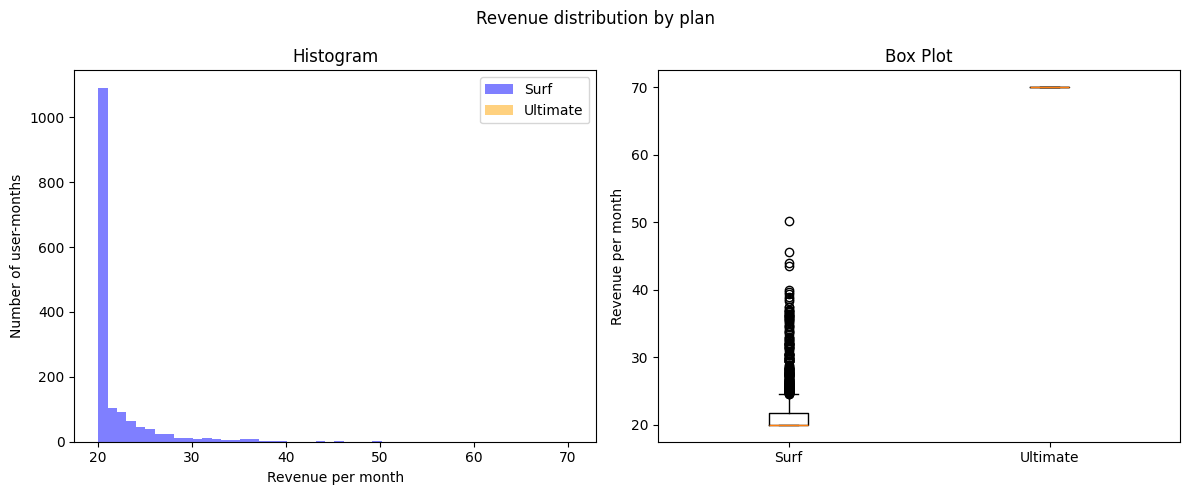

In [201]:
# Comparing the revenue distribution between Surf and Ultimate
# plan users using histogram and box plot side by side
surf_revenue = total_dataset[total_dataset['plan'] == 'surf']['revenue']
ultimate_revenue = total_dataset[total_dataset['plan'] == 'ultimate']['revenue']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(surf_revenue, bins=30, alpha=0.5, label='Surf', color='blue')
ax1.hist(ultimate_revenue, bins=30, alpha=0.5, label='Ultimate', color='orange')
ax1.set_title('Histogram')
ax1.set_xlabel('Revenue per month')
ax1.set_ylabel('Number of user-months')
ax1.legend()

ax2.boxplot([surf_revenue, ultimate_revenue], labels=['Surf', 'Ultimate'])
ax2.set_title('Box Plot')
ax2.set_ylabel('Revenue per month')

plt.suptitle('Revenue distribution by plan')
plt.tight_layout()
plt.show()


The revenue distribution clearly differs between the two plans.

Surf plan users show a wide revenue distribution. The majority pay
the base fee of $20, but a significant portion exceeds the package
limits and pays more (up to $50), resulting in high variance.
This suggests that Surf users frequently exceed their included
minutes, messages, and data allowances.

Ultimate plan users show almost no variance in revenue. Nearly all
users pay exactly the base fee of $70, with virtually no additional
charges. This indicates that the Ultimate plan limits are generous
enough that users rarely exceed them.

Although Ultimate generates higher fixed revenue per user ($70 vs $20),
the actual average revenue from Surf users may be closer to Ultimate
when overage charges are included.


## Test statistical hypotheses

Null hypothesis (H0): The average revenue from Ultimate and Surf plan
users is equal. There is no statistically significant difference
between the two groups.

Alternative hypothesis (H1): The average revenue from Ultimate and
Surf plan users is different. There is a statistically significant
difference between the two groups.

Alpha value: 0.05 (95% confidence level)

Statistical test: We use the independent samples t-test (ttest_ind)
because we are comparing the means of two independent groups (Surf
users and Ultimate users) and the data is continuous. If the resulting
p-value is less than 0.05, we reject the null hypothesis and conclude
that the revenues differ significantly between the two plans.

In [193]:
# Test the hypotheses
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

t_stat, p_value = stats.ttest_ind(surf_revenue, ultimate_revenue)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("The null hypothesis is rejected. The average revenue differs significantly between the two plans.")
else:
    print("The null hypothesis is not rejected. There is no significant difference in average revenue between the two plans.")


T-statistic: -370.7653
P-value: 0.0000
The null hypothesis is rejected. The average revenue differs significantly between the two plans.


The p-value is 0.0000, which is less than the alpha value of 0.05.
Therefore, we reject the null hypothesis. The average revenue from
Ultimate and Surf plan users differs significantly. Ultimate plan
generates higher and more stable revenue per user ($70 fixed), while
Surf plan shows more variable revenue with a lower average.

In [194]:
# Split data into NY-NJ and other regions
nynj_revenue = total_dataset[total_dataset['city'].str.contains('NY-NJ')]['revenue']
other_revenue = total_dataset[~total_dataset['city'].str.contains('NY-NJ')]['revenue']

# Test the hypothesis
t_stat, p_value = stats.ttest_ind(nynj_revenue, other_revenue)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("The null hypothesis is rejected. The average revenue differs significantly between NY-NJ and other regions.")
else:
    print("The null hypothesis is not rejected. There is no significant difference in average revenue between NY-NJ and other regions.")


T-statistic: -6.7447
P-value: 0.0000
The null hypothesis is rejected. The average revenue differs significantly between NY-NJ and other regions.


The p-value is 0.0000, which is less than the alpha value of 0.05.
Therefore, we reject the null hypothesis. The average revenue from
users in the NY-NJ area differs significantly from users in other
regions. This suggests that geographic location has a statistically
significant impact on revenue.

## General conclusion

Overall Conclusion

This project analyzed the behavior and revenue of 500 Megaline
customers using two prepaid plans: Surf and Ultimate.

Data Preparation:
The data was cleaned by converting date columns to datetime format,
rounding call durations up to the nearest minute, and calculating
monthly usage metrics (calls, minutes, messages, and data) for each user.

User Behavior:
Surf plan users frequently exceed their package limits, resulting in
variable revenue around the $20 base fee. Ultimate plan users rarely
exceed their generous limits, paying a stable $70 monthly fee and
showing very predictable usage patterns.

Revenue Analysis:
Ultimate plan generates higher and more stable revenue per user ($70
fixed monthly fee) compared to Surf ($20 base fee with variable overage
charges). However, Surf users who exceed their limits also contribute
additional revenue through overage charges.

Hypothesis Testing:
Both statistical hypotheses were rejected (p-value = 0.0000):
- Ultimate plan generates significantly higher revenue than Surf.
- NY-NJ region users show significantly different revenue compared
to other regions, indicating that geographic location impacts revenue.

Recommendation:
The Ultimate plan is more profitable and stable per user. The advertising
budget should prioritize promoting the Ultimate plan, with special focus
on high-revenue regions like NY-NJ, where Surf users also show potential
for higher overage charges and possible plan upgrades.